In [1]:
import kagglehub
path = kagglehub.dataset_download("jeffheaton/glasses-or-no-glasses")

print("Path:", path)

Path: /kaggle/input/datasets/jeffheaton/glasses-or-no-glasses


In [2]:
import os
import shutil

src_img_path = "/kaggle/input/datasets/jeffheaton/glasses-or-no-glasses/faces-spring-2020/faces-spring-2020"

dst_base = "/kaggle/working/glassesdata/"
img_path = os.path.join(dst_base, "images")
train_folder = os.path.join(dst_base, "train")
test_folder = os.path.join(dst_base, "test")

os.makedirs(img_path, exist_ok=True)
os.makedirs(train_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)

for img_name in os.listdir(src_img_path):
    if img_name.startswith("face-") and img_name.endswith(".png"):
        new_name = img_name.replace("face-", "")
        src = os.path.join(src_img_path, img_name)
        dst = os.path.join(img_path, new_name)
        if not os.path.exists(dst):  # avoid recopying if already done
            shutil.copy(src, dst)

images = sorted(
    [f for f in os.listdir(img_path) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for img_name in images[:4500]:
    src = os.path.join(img_path, img_name)
    dst = os.path.join(train_folder, img_name)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

for img_name in images[4500:5000]:
    src = os.path.join(img_path, img_name)
    dst = os.path.join(test_folder, img_name)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("dataset copied and split into /kaggle/working/glassesdata/train and /kaggle/working/glassesdata/test")

dataset copied and split into /kaggle/working/glassesdata/train and /kaggle/working/glassesdata/test


In [3]:
import pandas as pd
import shutil
import os

base_path = "/kaggle/working/glassesdata"

csv_path = "/kaggle/input/datasets/anvik029/correct-train/train_1.csv"
df = pd.read_csv(csv_path)

glasses_folder = os.path.join(train_folder, "glasses")
no_glasses_folder = os.path.join(train_folder, "no_glasses")
os.makedirs(glasses_folder, exist_ok=True)
os.makedirs(no_glasses_folder, exist_ok=True)

for idx, row in df.iterrows():
    img_name = f"{int(row['id'])}.png"  
    src = os.path.join(train_folder, img_name)

    if not os.path.exists(src):
        print(f"Image {img_name} not found, skipping...")
        continue

    dst = glasses_folder if row['glasses'] == 1 else no_glasses_folder
    shutil.move(src, os.path.join(dst, img_name))

print("train folder segregated into glasses and no_glasses")

train folder segregated into glasses and no_glasses


In [4]:
base_path = "/kaggle/working/glassesdata/"
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files[:3]:  # show only 3 files for preview
        print(f"{subindent}{f}")

/
images/
  2536.png
  3164.png
  1085.png
train/
  no_glasses/
    2536.png
    3164.png
    1085.png
  glasses/
    2919.png
    4430.png
    1569.png
test/
  4545.png
  4701.png
  4544.png


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    # transforms.Resize((64,64)),
    # transforms.ToTensor(),
    # transforms.Normalize([0.5],[0.5])

    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    
])

train_data = datasets.ImageFolder(train_folder, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4,pin_memory=True)

print("Classes:", train_data.classes)  # ['glasses', 'no_glasses']

Classes: ['glasses', 'no_glasses']


In [6]:
import torch.nn as nn

z_dim = 128  # latent vector size
class Generator(nn.Module):
    def __init__(self, z_dim=128, img_channels=3, feature_g=32):  
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feature_g*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*8, feature_g*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*4, feature_g*2, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(feature_g*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*2, feature_g, 4, 2, 1, bias=False),  
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),  
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_d=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, 4, 2, 1, bias=False),   
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d, feature_d*2, 4, 2, 1, bias=False),  
            nn.BatchNorm2d(feature_d*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d*2, feature_d*4, 4, 2, 1, bias=False),  
            nn.BatchNorm2d(feature_d*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d*4, feature_d*8, 4, 2, 1, bias=False),  
            nn.BatchNorm2d(feature_d*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_d*8, 1, 4, 1, 0, bias=False)             
        )

    def forward(self, img):
        return self.net(img).view(-1, 1) 

In [7]:
import random
import torchvision.transforms.functional as TF

def adaptive_augment(image, p=0.2):
    # augmentations with probability p
    if random.random() < p: image = TF.hflip(image)
    if random.random() < p: image = TF.adjust_brightness(image, 0.8 + 0.4*random.random())
    if random.random() < p: image = TF.adjust_contrast(image, 0.8 + 0.4*random.random())
    return image

In [8]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [9]:
import torch
import torch.optim as optim
import torchvision.utils as vutils
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt 
import torch.nn as nn

G = Generator().to(device)
D = Discriminator().to(device)

if torch.cuda.device_count() > 1:
    G = nn.DataParallel(G)
    D = nn.DataParallel(D)


scaler = torch.amp.GradScaler(device)
criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 50
fixed_noise = torch.randn(6, z_dim, 1, 1, device=device)

save_path = "/kaggle/working/GAN_Checkpoints"
import os
os.makedirs(save_path, exist_ok=True)


Epoch 1/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/71 [00:00<?, ?it/s]

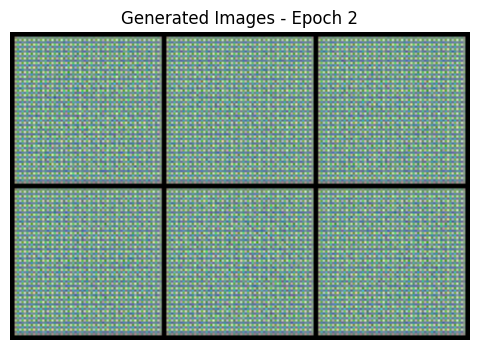

Epoch 3/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/71 [00:00<?, ?it/s]

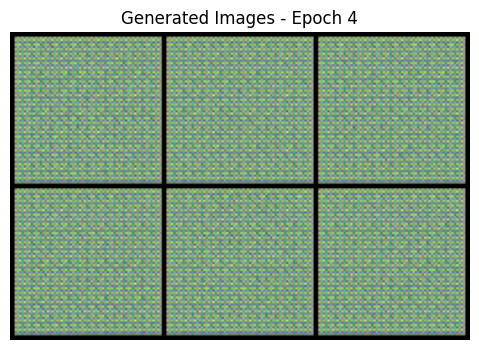

Epoch 5/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 6/50:   0%|          | 0/71 [00:00<?, ?it/s]

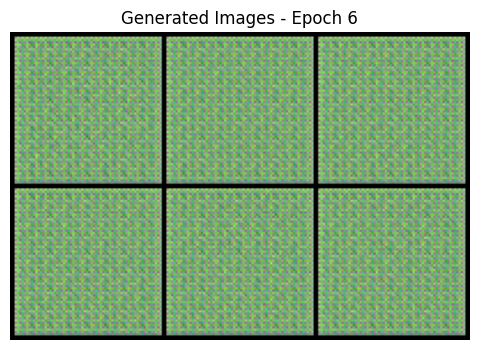

Epoch 7/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 8/50:   0%|          | 0/71 [00:00<?, ?it/s]

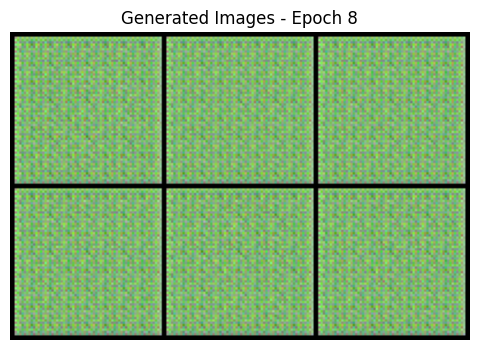

Epoch 9/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 10/50:   0%|          | 0/71 [00:00<?, ?it/s]

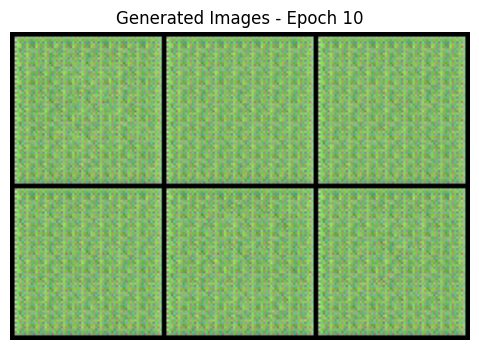

Epoch 11/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 12/50:   0%|          | 0/71 [00:00<?, ?it/s]

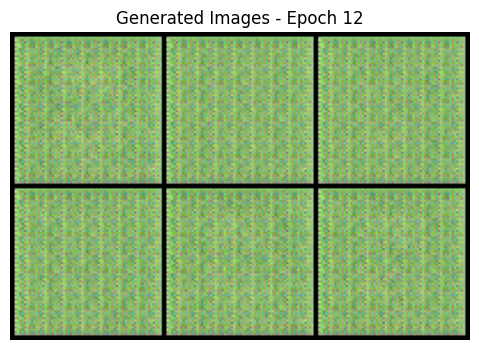

Epoch 13/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 14/50:   0%|          | 0/71 [00:00<?, ?it/s]

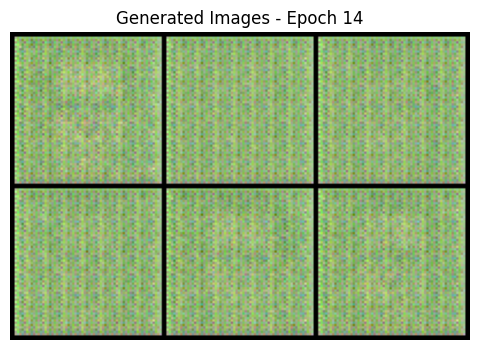

Epoch 15/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 16/50:   0%|          | 0/71 [00:00<?, ?it/s]

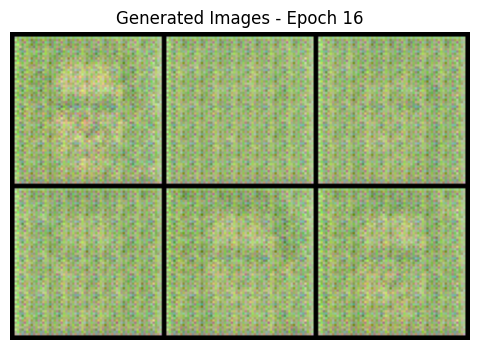

Epoch 17/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 18/50:   0%|          | 0/71 [00:00<?, ?it/s]

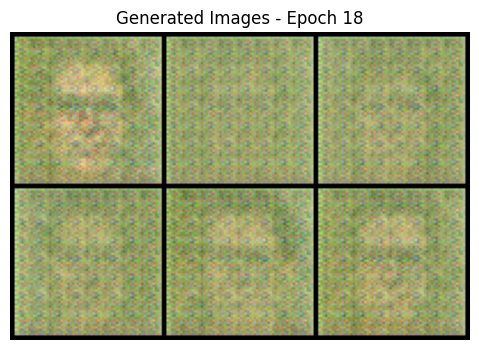

Epoch 19/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 20/50:   0%|          | 0/71 [00:00<?, ?it/s]

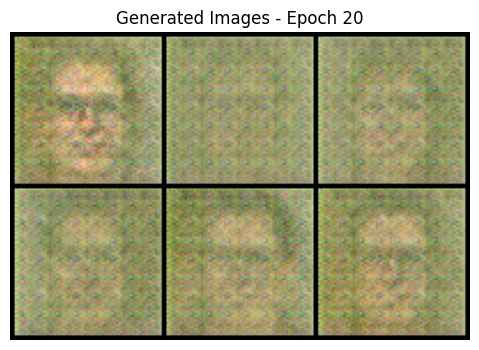

Epoch 21/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 22/50:   0%|          | 0/71 [00:00<?, ?it/s]

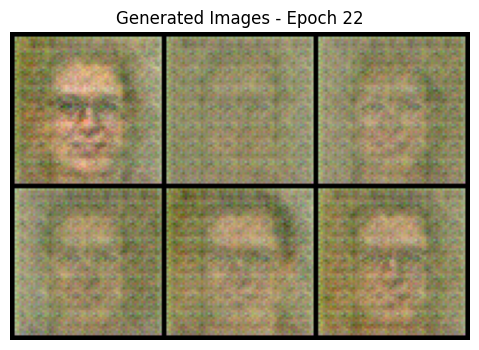

Epoch 23/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 24/50:   0%|          | 0/71 [00:00<?, ?it/s]

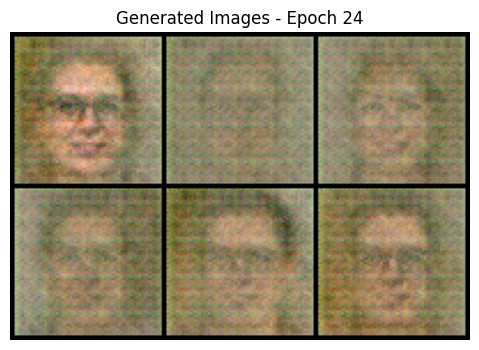

Epoch 25/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 26/50:   0%|          | 0/71 [00:00<?, ?it/s]

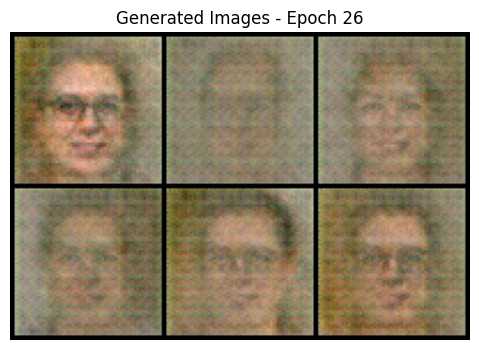

Epoch 27/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 28/50:   0%|          | 0/71 [00:00<?, ?it/s]

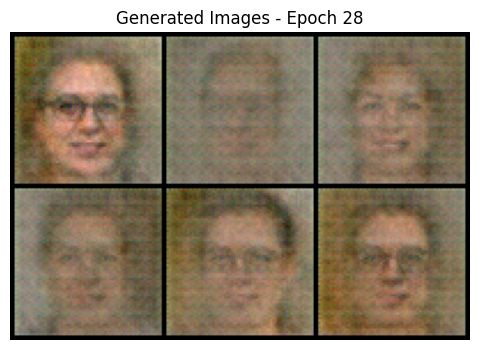

Epoch 29/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 30/50:   0%|          | 0/71 [00:00<?, ?it/s]

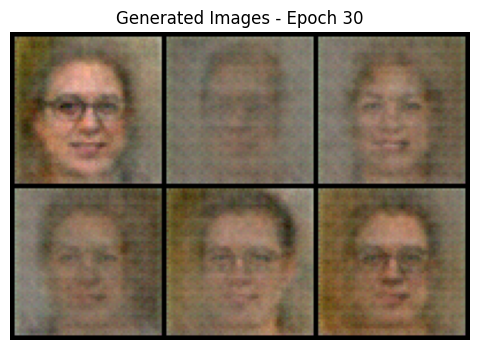

Epoch 31/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 32/50:   0%|          | 0/71 [00:00<?, ?it/s]

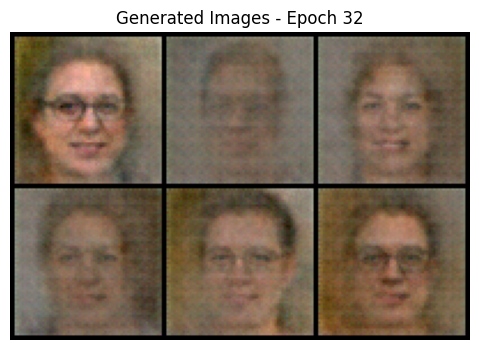

Epoch 33/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 34/50:   0%|          | 0/71 [00:00<?, ?it/s]

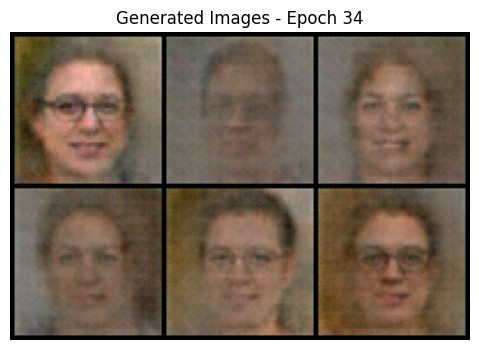

Epoch 35/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 36/50:   0%|          | 0/71 [00:00<?, ?it/s]

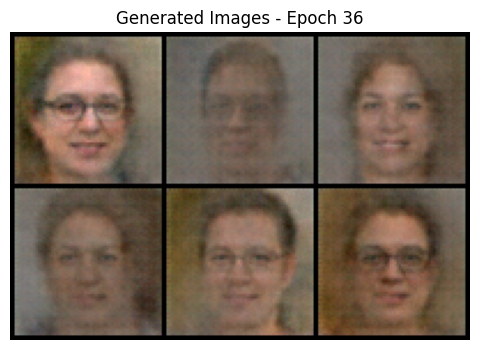

Epoch 37/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 38/50:   0%|          | 0/71 [00:00<?, ?it/s]

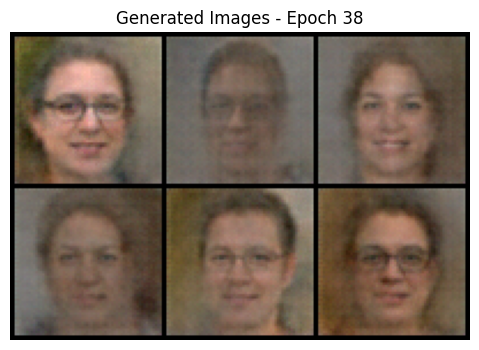

Epoch 39/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 40/50:   0%|          | 0/71 [00:00<?, ?it/s]

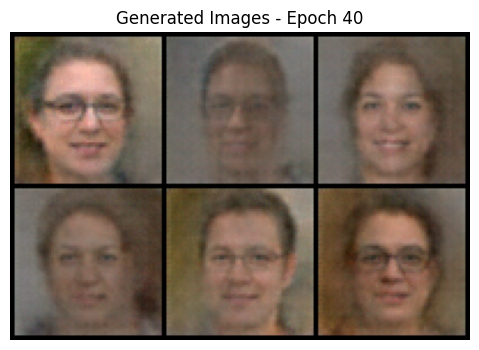

Epoch 41/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 42/50:   0%|          | 0/71 [00:00<?, ?it/s]

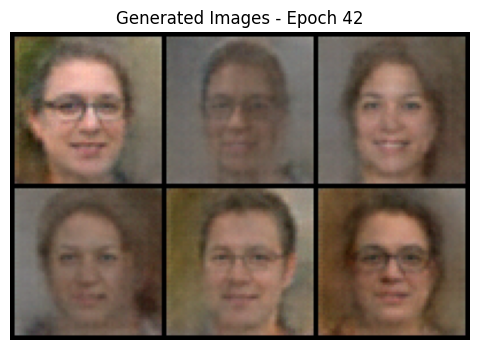

Epoch 43/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 44/50:   0%|          | 0/71 [00:00<?, ?it/s]

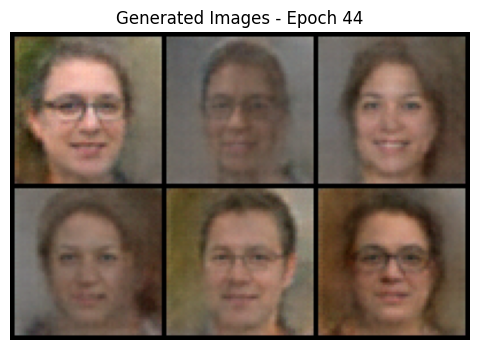

Epoch 45/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 46/50:   0%|          | 0/71 [00:00<?, ?it/s]

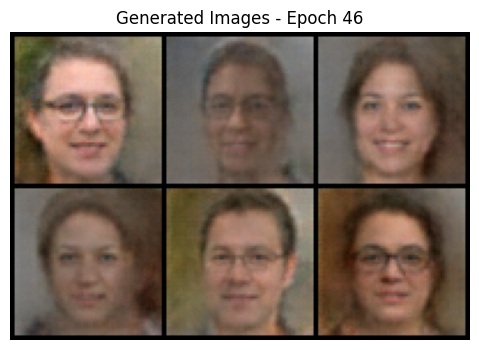

Epoch 47/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/71 [00:00<?, ?it/s]

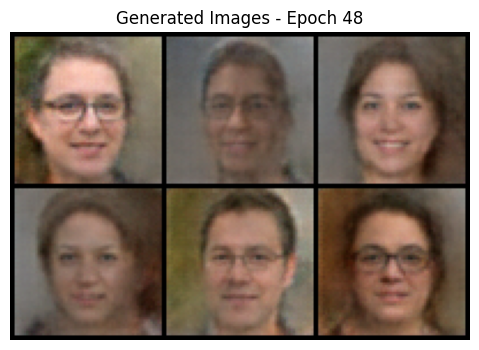

Epoch 49/50:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/71 [00:00<?, ?it/s]

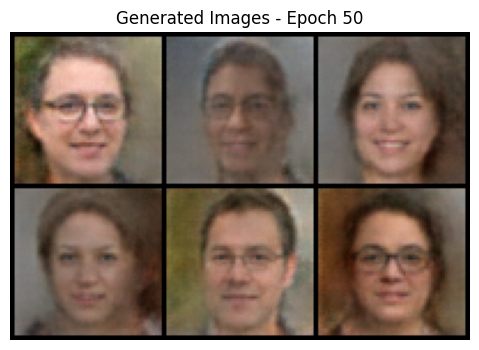

In [10]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.shadow[k] * self.decay + v * (1.0 - self.decay)

    def apply(self, model):
        model.load_state_dict(self.shadow)

def smooth_labels(labels, smoothing=0.1):
    return labels * (1.0 - smoothing) + 0.5 * smoothing

ema = EMA(G.module if isinstance(G, nn.DataParallel) else G, decay=0.999)

G_losses = []
D_losses = []
D_real_acc = []
D_fake_acc = []

for epoch in range(epochs):
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")

    for i, (imgs, _) in loop:
        imgs = imgs.to(device)
        bs = imgs.size(0)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)
        real_labels = smooth_labels(real_labels, smoothing=0.05)
        fake_labels = smooth_labels(fake_labels, smoothing=0.05)
        
        # discriminator
        aug_imgs = adaptive_augment(imgs) 
        
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
            real_out = D(aug_imgs)
            d_loss_real = criterion(real_out, real_labels)
            
            z = torch.randn(bs, z_dim, 1, 1, device=device)
            fake_imgs = G(z)
            fake_out = D(fake_imgs.detach())
            d_loss_fake = criterion(fake_out, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            D_losses.append(d_loss.item())
            
            with torch.no_grad():
                real_pred = torch.sigmoid(real_out)
                fake_pred = torch.sigmoid(fake_out)
            
                real_acc = (real_pred > 0.5).float().mean().item()
                fake_acc = (fake_pred < 0.5).float().mean().item()
            
            D_real_acc.append(real_acc)
            D_fake_acc.append(fake_acc)

        opt_D.zero_grad()
        scaler.scale(d_loss).backward()
        scaler.step(opt_D)
        scaler.update()

        with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
            z_g = torch.randn(bs, z_dim, 1, 1, device=device)   
            gen_imgs = G(z_g)                                  
            fake_out_for_g = D(gen_imgs)           
            g_loss = criterion(fake_out_for_g, real_labels)
            G_losses.append(g_loss.item())
        
        opt_G.zero_grad()
        scaler.scale(g_loss).backward()
        scaler.step(opt_G)
        scaler.update()
        
        ema.update(G.module if isinstance(G, nn.DataParallel) else G)

    torch.save({
        "epoch": epoch+1,
        "generator_state_dict": G.state_dict(),
        "discriminator_state_dict": D.state_dict(),
        "opt_G_state_dict": opt_G.state_dict(),
        "opt_D_state_dict": opt_D.state_dict(),
        "scaler": scaler.state_dict()
    }, f"{save_path}/GAN_epoch_{epoch+1}.pth")

    if (epoch+1) % 2 == 0:
        G_ema = Generator(z_dim=z_dim).to(device)
        G_ema.load_state_dict(ema.shadow, strict=False)
        G_ema.eval()
    
        with torch.no_grad():
            fake_samples = G_ema(fixed_noise).detach().cpu()
            
        grid = vutils.make_grid(fake_samples, nrow=3, padding=2, normalize=True)
        plt.figure(figsize=(6,4))
        plt.axis("off")
        plt.title(f"Generated Images - Epoch {epoch+1}")
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.show()


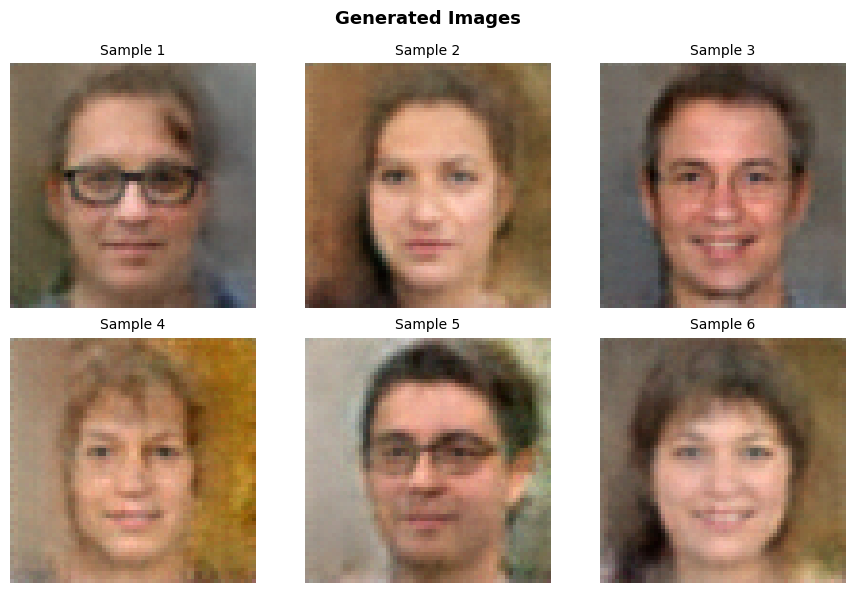

In [15]:
G_ema = Generator(z_dim=z_dim).to(device)
G_ema.load_state_dict(ema.shadow, strict=False)
G_ema.eval()

with torch.no_grad():
    sample_noise = torch.randn(6, z_dim, 1, 1, device=device)  
    generated = G_ema(sample_noise).detach().cpu()              

fig, axes = plt.subplots(2, 3, figsize=(9, 6))                 
for idx, ax in enumerate(axes.flat):
    img = generated[idx]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)    
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.axis("off")
    ax.set_title(f"Sample {idx+1}", fontsize=10)

plt.suptitle("Generated Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
torch.save({
    "epoch": epochs,
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "opt_G_state_dict": opt_G.state_dict(),
    "opt_D_state_dict": opt_D.state_dict(),
    "scaler": scaler.state_dict(),
    "ema_shadow": ema.shadow,
}, f"{save_path}/GAN_final.pth")

torch.save(
    ema.shadow,
    f"{save_path}/G_ema_final.pth"
)

print(f"Saved final checkpoint → {save_path}/GAN_final.pth")
print(f"Saved EMA generator   → {save_path}/G_ema_final.pth")


Saved final checkpoint → /kaggle/working/GAN_Checkpoints/GAN_final.pth
Saved EMA generator   → /kaggle/working/GAN_Checkpoints/G_ema_final.pth


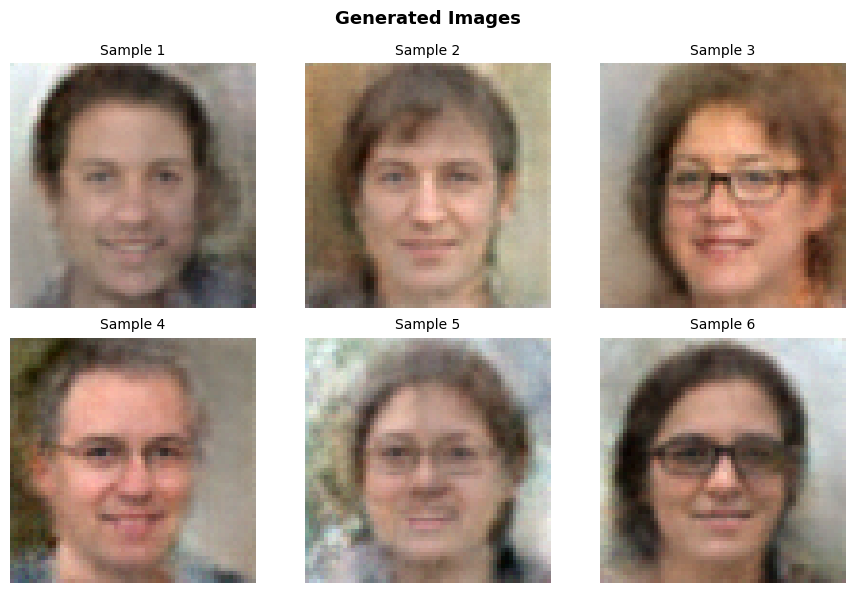

In [20]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim    = 128
save_path = "checkpoints"

ckpt = torch.load(f"/kaggle/working/GAN_Checkpoints/GAN_final.pth", map_location=device)

G_ema = Generator(z_dim=z_dim).to(device)
G_ema.load_state_dict(ckpt["ema_shadow"], strict=False)
G_ema.eval()

with torch.no_grad():
    sample_noise = torch.randn(6, z_dim, 1, 1, device=device)
    generated    = G_ema(sample_noise).detach().cpu()

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for idx, ax in enumerate(axes.flat):
    img = generated[idx]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.axis("off")
    ax.set_title(f"Sample {idx+1}", fontsize=10)

plt.suptitle("Generated Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


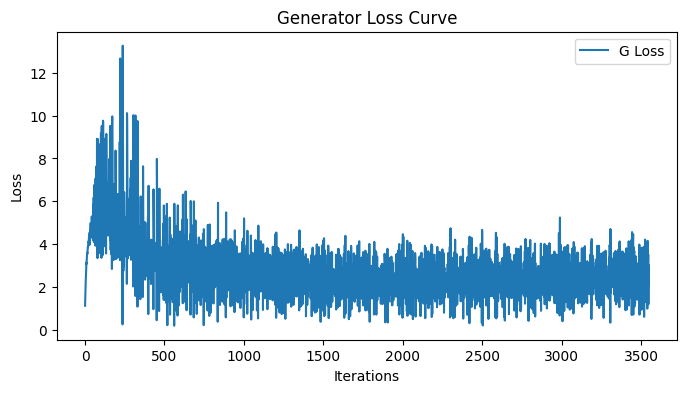

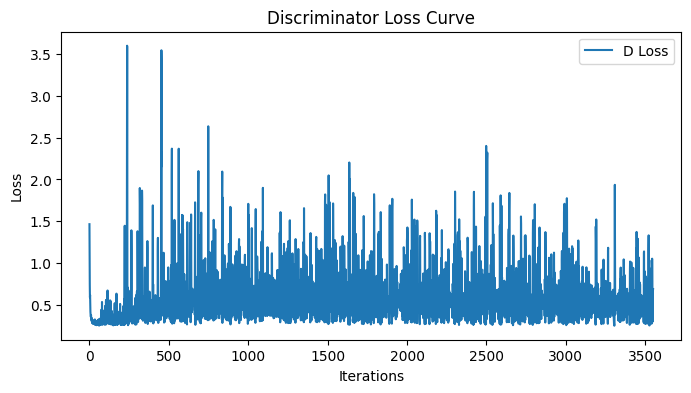

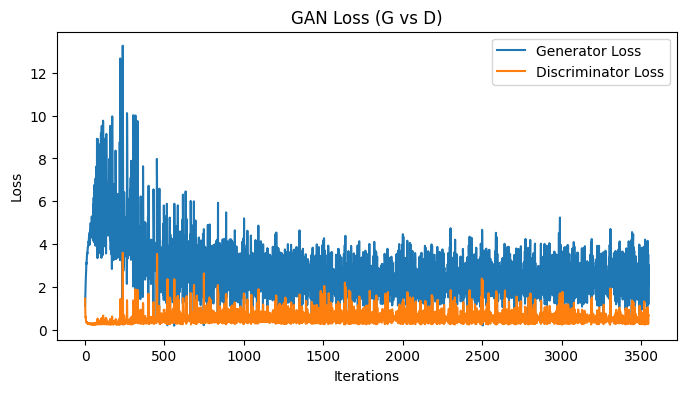

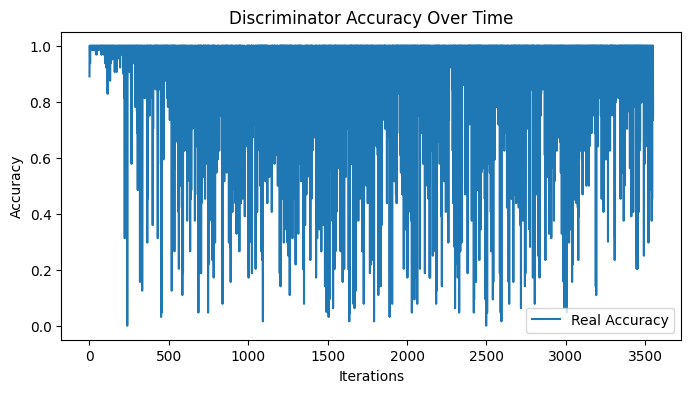

In [22]:
plt.figure(figsize=(8,4))
plt.plot(G_losses, label="G Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Generator Loss Curve")
plt.legend()
plt.show()

# === Plot Discriminator Loss ===
plt.figure(figsize=(8,4))
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Discriminator Loss Curve")
plt.legend()
plt.show()

# === Combined Loss ===
plt.figure(figsize=(8,4))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("GAN Loss (G vs D)")
plt.legend()
plt.show()

# === D Accuracy ===
plt.figure(figsize=(8,4))
plt.plot(D_real_acc, label="Real Accuracy")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Discriminator Accuracy Over Time")
plt.legend()
plt.show()

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy import linalg
from scipy.stats import entropy

N_SAMPLES   = 4000   
BATCH_SIZE  = 64
NUM_WORKERS = 4

G_eval = Generator(z_dim=z_dim).to(device)
G_eval.load_state_dict(ema.shadow, strict=False)
G_eval.eval()

#generate fake images
print(f"Generating {N_SAMPLES} fake images...")
all_fake = []
with torch.no_grad():
    while sum(t.shape[0] for t in all_fake) < N_SAMPLES:
        z = torch.randn(BATCH_SIZE, z_dim, 1, 1, device=device)
        imgs = G_eval(z).cpu()
        all_fake.append(imgs)
fake_tensor = torch.cat(all_fake, dim=0)[:N_SAMPLES] 
print(f"Fake images shape: {fake_tensor.shape}")

#generate real images
print(f"Loading {N_SAMPLES} real images...")
real_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

trainfolder="/kaggle/working/glassesdata/train"
real_dataset = datasets.ImageFolder(trainfolder, transform=real_transform)
real_loader  = DataLoader(real_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS)
all_real = []
with torch.no_grad():
    for imgs, _ in real_loader:
        all_real.append(imgs)
        if sum(t.shape[0] for t in all_real) >= N_SAMPLES:
            break
real_tensor = torch.cat(all_real, dim=0)[:N_SAMPLES]
print(f"Real images shape: {real_tensor.shape}")

print("Loading Inception-v3...")
weights = Inception_V3_Weights.DEFAULT

inception_feat = inception_v3(weights=weights, transform_input=False)
inception_feat.fc = nn.Identity()        
inception_feat.aux_logits = False
inception_feat = inception_feat.to(device).eval()

inception_cls = inception_v3(weights=weights, transform_input=False)
inception_cls.aux_logits = False
inception_cls = inception_cls.to(device).eval()
print("Inception-v3 loaded")

@torch.no_grad()
def get_features(img_tensor, model, batch_size=32):
    """Extract 2048-d pool3 features for FID."""
    feats = []
    for i in range(0, img_tensor.shape[0], batch_size):
        batch = img_tensor[i : i + batch_size].to(device)
        # Inception-v3 expects 299×299 input
        batch = nn.functional.interpolate(
            batch, size=(299, 299), mode="bilinear", align_corners=False
        )
        feats.append(model(batch).cpu().numpy())
    return np.concatenate(feats, axis=0)

print("Extracting Inception features (real)...")
real_feats = get_features(real_tensor, inception_feat)
print("Extracting Inception features (fake)...")
fake_feats = get_features(fake_tensor, inception_feat)

#fid compute
def compute_fid(real_f, fake_f):
    mu_r, sigma_r = real_f.mean(0), np.cov(real_f, rowvar=False)
    mu_f, sigma_f = fake_f.mean(0), np.cov(fake_f, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean))

fid = compute_fid(real_feats, fake_feats)

#is compute
@torch.no_grad()
def compute_is(img_tensor, model, batch_size=32, splits=10):
    preds = []
    for i in range(0, img_tensor.shape[0], batch_size):
        batch = img_tensor[i : i + batch_size].to(device)
        batch = nn.functional.interpolate(
            batch, size=(299, 299), mode="bilinear", align_corners=False
        )
        logits = model(batch)                          
        preds.append(torch.softmax(logits, dim=1).cpu().numpy())
    preds = np.concatenate(preds, axis=0)               

    chunk = preds.shape[0] // splits
    scores = []
    for k in range(splits):
        part = preds[k * chunk : (k + 1) * chunk]
        py   = part.mean(axis=0)                     
        scores.append(np.exp(np.mean([entropy(p, py) for p in part])))
    return float(np.mean(scores)), float(np.std(scores))

is_mean, is_std = compute_is(fake_tensor, inception_cls)

print("\n" + "="*45)
print(f"  Image Generation Metrics")
print("="*45)
print(f"  FID  = {fid:.2f}   (lower is better)")
print(f"  IS   = {is_mean:.3f} ± {is_std:.3f}  (higher is better)")
print("="*45)
print(f"\n  Evaluated on {N_SAMPLES} real + {N_SAMPLES} fake images")

Generating 4000 fake images...
Fake images shape: torch.Size([4000, 3, 64, 64])
Loading 4000 real images...
Real images shape: torch.Size([4000, 3, 64, 64])
Loading Inception-v3...
Inception-v3 loaded
Extracting Inception features (real)...
Extracting Inception features (fake)...


/tmp/ipykernel_55/2918391594.py:87: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)



  Image Generation Metrics
  FID  = 102.90   (lower is better)
  IS   = 1.348 ± 0.011  (higher is better)

  Evaluated on 4000 real + 4000 fake images
